Sequence Manipulation :

a. Find and display the length of Sequence A and B.

b. Find and display which index the first time codon (ATC) appears in both Sequence
A and B.

c. Take the first 15 nucleotides from Sequence A, and the last 35 nucleotides from
Sequence B. Then combine the sequences and reverse it to a new sequence,
Sequence C.



In [30]:
%pip install BioPython
import Bio


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
from Bio import SeqIO
seqA = SeqIO.read('/workspaces/Computational_Biolgy/latsoal_combio_2/a.fasta', 'fasta')
seqB = SeqIO.read('/workspaces/Computational_Biolgy/latsoal_combio_2/b.fasta', 'fasta')

print(seqA)
print(seqB)

ID: NM_032476.4
Name: NM_032476.4
Description: NM_032476.4 Homo sapiens mitochondrial ribosomal protein S6 (MRPS6), mRNA
Number of features: 0
Seq('GCTTTCGCCGCCTGGGAGCCGTCCGGCGCAGCAGTTTCTAGGTCCCCACTGTCC...GAA')
ID: DI342112.1
Name: DI342112.1
Description: DI342112.1 KR 1020130014673-A/24: Escherichia genus microorganism having deleted or amplified YbbO gene and Method of producing retinoids using the same
Number of features: 0
Seq('ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGGTC...TGA')


In [32]:
# The length of the both sequence
print(f"Sequence A Length = {len(seqA)}")
print(f"Sequence B Length = {len(seqB)}")

Sequence A Length = 931
Sequence B Length = 810


In [33]:
#Find and display which index the first time codon (ATC) appears in both Sequence A and B.

seqAA = str(seqA.seq)
seqBB = str(seqB.seq)

print(f"ATC in Sequence A first appear in = {seqAA.index('ATC')}")
print(f"ATC in Sequence A first appear in = {seqBB.index('ATC')}")

ATC in Sequence A first appear in = 112
ATC in Sequence A first appear in = 21


In [34]:
# Take the first 15 nucleotides from Sequence A, and the last 35 nucleotides from
# Sequence B. Then combine the sequences and reverse it to a new sequence,
# Sequence C.

seqC = seqAA[0:15] + seqBB[(len(seqBB)-35):] 
seqC = seqC[::-1]

print(f"Sequence C = {seqC}")

Sequence C = AGTGGGGACGTTATAAAACAGGTAGTGCGCGGGGCGGTCCGCCGCTTTCG


Sequence Analysis & Plotting :

a. Determine and display the nucleotides base (A, C, G, T) frequency for Sequence
A, B, and C with a chart using matplotlib library.

b. Determine and display the GC & AT content percentage for Sequence A, B, and C.

c. Determine and display the melting temperature for Sequence A, B, and C (using
built-in Wallace, Nearest Neighbor, and GC Method).

d. Determine and display the molecular weight for Sequence A, B, and C.

In [35]:
%pip install matplotlib
from matplotlib import pyplot as plt
from collections import Counter



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


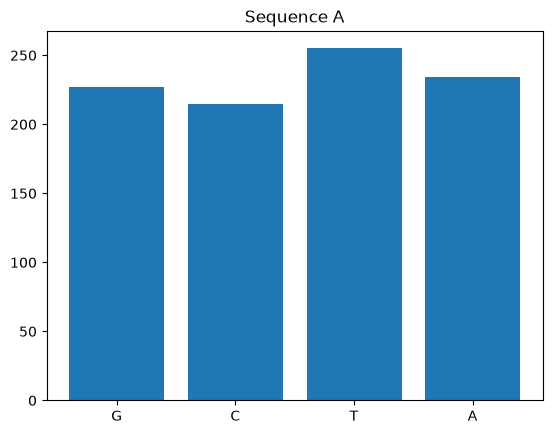

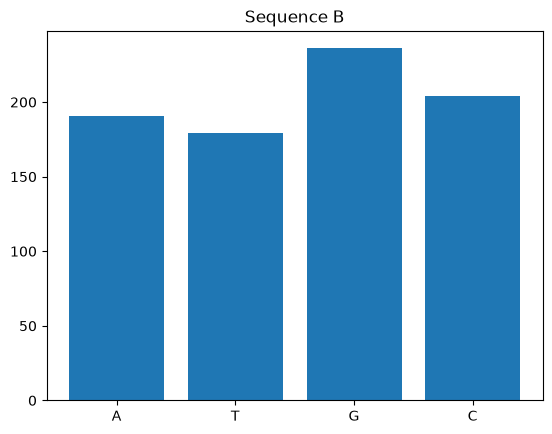

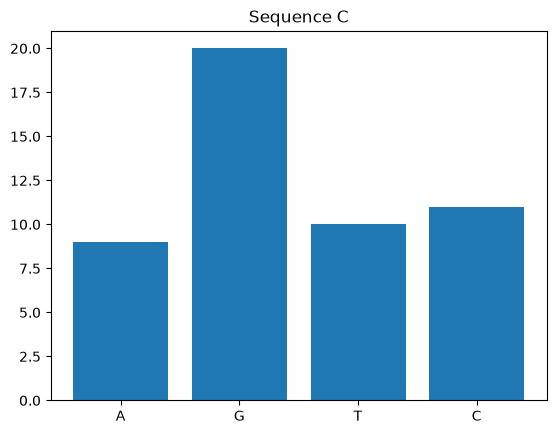

In [36]:
# Sequence A
dna_freqA = Counter(seqAA)
plt.bar(dna_freqA.keys(),dna_freqA.values())
plt.title('Sequence A')
plt.show()

# Sequence B
dna_freqB = Counter(seqBB)
plt.bar(dna_freqB.keys(),dna_freqB.values())
plt.title('Sequence B')
plt.show()

# Sequence B
dna_freqC = Counter(seqC)
plt.bar(dna_freqC.keys(),dna_freqC.values())
plt.title('Sequence C')
plt.show()


In [37]:
def GC_counter(seq):
    gc = [x for x in seq if x == 'G' or x == 'C']
    return len(gc)/len(seq)


def AT_counter(seq):
    at = [x for x in seq if x in 'AT']
    return len(at)/len(seq)


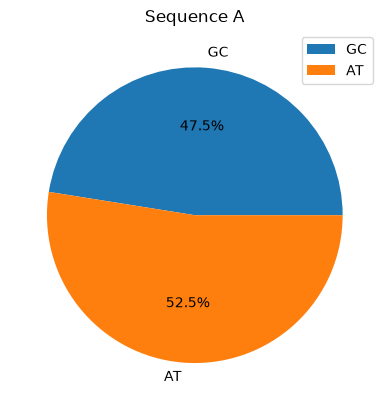

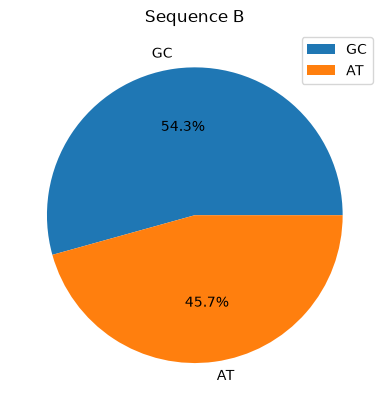

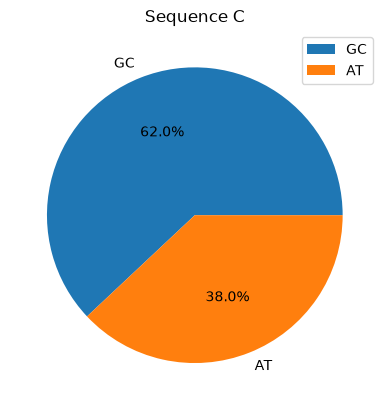

In [38]:
# Sequence A
plt.pie([GC_counter(seqAA), AT_counter(seqAA)], labels=['GC', 'AT'], autopct='%1.1f%%')
plt.title('Sequence A')
plt.legend(["GC", "AT"])
plt.show()

# Sequence B
plt.pie([GC_counter(seqBB), AT_counter(seqBB)], labels=['GC', 'AT'], autopct='%1.1f%%')
plt.title('Sequence B')
plt.legend(["GC", "AT"])
plt.show()

# Sequence B
plt.pie([GC_counter(seqC), AT_counter(seqC)], labels=['GC', 'AT'], autopct='%1.1f%%')
plt.title('Sequence C')
plt.legend(["GC", "AT"])
plt.show()

In [39]:
# Determine melting tempetaure with Walace method
from Bio.SeqUtils import MeltingTemp as mt
print(f" Melting point sequence A with Walace {mt.Tm_Wallace(seqAA)}")
print(f" Melting point sequence B with Walace {mt.Tm_Wallace(seqBB)}")
print(f" Melting point sequence C with Walace {mt.Tm_Wallace(seqC)}")

 Melting point sequence A with Walace 2746.0
 Melting point sequence B with Walace 2500.0
 Melting point sequence C with Walace 162.0


In [40]:
# Determine melting tempetaure with Nearest Neighbor
print(f" Melting point sequence A with Nearest Neighbor {mt.Tm_NN(seqAA)}")
print(f" Melting point sequence B with Nearest Neighbor {mt.Tm_NN(seqBB)}")
print(f" Melting point sequence C with Nearest Neighbor {mt.Tm_NN(seqC)}")

 Melting point sequence A with Nearest Neighbor 81.50962600687961
 Melting point sequence B with Nearest Neighbor 84.89757391385137
 Melting point sequence C with Nearest Neighbor 76.39147904221767


In [41]:
# Determine melting tempetaure with GC Method
print(f" Melting point sequence A with GC {mt.Tm_GC(seqAA)}")
print(f" Melting point sequence B with GC {mt.Tm_GC(seqBB)}")
print(f" Melting point sequence C with GC {mt.Tm_GC(seqC)}")

 Melting point sequence A with GC 78.72352505801443
 Melting point sequence B with GC 81.43376626950877
 Melting point sequence C with GC 73.32290207197791


In [42]:
from Bio.SeqUtils import molecular_weight
print(f"Molecular Weight of Sequence A = {molecular_weight(seqAA, seq_type='DNA')}") 
print(f"Molecular Weight of Sequence B = {molecular_weight(seqBB, seq_type='DNA')}") 
print(f"Molecular Weight of Sequence C = {molecular_weight(seqC, seq_type='DNA')}") 

Molecular Weight of Sequence A = 287781.4286
Molecular Weight of Sequence B = 250976.7192
Molecular Weight of Sequence C = 15643.923599999998


DNA & mRNA Protein Synthesis:

a. Transcribe and display the DNA Sequence A, B, and C into mRNA Sequences.

b. Translate and display the mRNA Sequence A, B, and C into amino acids
sequences. 


In [43]:
from Bio.Seq import Seq

mRNA_seqA = Seq(seqAA).transcribe()
mRNA_seqB = Seq(seqBB).transcribe()
mRNA_seqC = Seq(seqC).transcribe()

print(f"mRNA sequence A = {mRNA_seqA}")
print(f"mRNA sequence B = {mRNA_seqB}")
print(f"mRNA sequence C = {mRNA_seqC}")


mRNA sequence A = GCUUUCGCCGCCUGGGAGCCGUCCGGCGCAGCAGUUUCUAGGUCCCCACUGUCCCCGCCGUCCCGCCCCUUCGCGUCCCGGGAACCGGCUGGCUUCCGAGCCGCACUCGCCGAUCCUCCAGGCAUGCCCCGCUACGAGCUGGCUUUAAUCCUGAAAGCCAUGCAGCGGCCAGAGACUGCUGCUACUUUGAAACGUACGAUAGAGGCCCUGAUGGACAGAGGAGCAAUAGUGAGGGACUUGGAAAACCUGGGUGAACGAGCGCUUCCUUAUAGGAUCUCUGCCCACAGUCAGCAGCACAACAGAGGCGGGUAUUUCUUGGUGGAUUUUUAUGCACCCACCGCAGCUGUUGAAAGCAUGGUGGAGCACUUGUCUCGAGAUAUAGAUGUGAUUAGAGGGAAUAUUGUCAAACACCCUCUGACCCAGGAACUAAAAGAAUGUGAAGGGAUUGUCCCAGUCCCACUCGCAGAAAAAUUAUAUUCCACAAAGAAGAGGAAGAAGUGAGAAGAUUCGCCAGAUUUUAGCCUUAUAUGUAAUUCCUUCACAUUUGGGCAGCAUGGACGAGAAGGAAGAAUUUGCAAGUUUGGCCUUUAUAUAAGCAUGUGUUGCAGGUGCUGUUUGAUUUUUCUAAGGUAUUUUUAGCCCUUGAUCCCCUUUGCUUGCGAGAGGUGGGGAACUGCUCACUGACAGCUUCUCUGUAACCUGCAGUACCAGUGGAUCGUUCUUGAUUUUGUUUUCAUUAGUGUCAUUUCUUUGUCAUUGAGGACUUUUCCCCUUACAACAGUAACACCAUUUUUUGAAGAGCAAAACUUAUAAUACCUCCUGGGAUUGUGAGCUAGUCAUUCAGCCUGUGUAACCAUGUGGAAAUAAAAAUUGACGACCAAUGUAUUAUAUGGACAACUUUUGCUUUGAGUAAUAAACUUGAUUGUAGGAA
mRNA sequence B = AUGACUCAUAAAGCAACGGAGAUCCUGACAGG

In [44]:
aminoAcid_seqA = mRNA_seqA.translate()
aminoAcid_seqB = mRNA_seqB.translate()
aminoAcid_seqC = mRNA_seqC.translate()

print(f"Amino acid sequence A: {aminoAcid_seqA}")
print(f"Amino acid sequence B: {aminoAcid_seqB}")
print(f"Amino acid sequence C: {aminoAcid_seqC}")

Amino acid sequence A: AFAAWEPSGAAVSRSPLSPPSRPFASREPAGFRAALADPPGMPRYELALILKAMQRPETAATLKRTIEALMDRGAIVRDLENLGERALPYRISAHSQQHNRGGYFLVDFYAPTAAVESMVEHLSRDIDVIRGNIVKHPLTQELKECEGIVPVPLAEKLYSTKKRKK*EDSPDFSLICNSFTFGQHGREGRICKFGLYISMCCRCCLIFLRYF*PLIPFACERWGTAH*QLLCNLQYQWIVLDFVFISVISLSLRTFPLTTVTPFFEEQNL*YLLGL*ASHSACVTMWK*KLTTNVLYGQLLL*VINLIVG
Amino acid sequence B: MTHKATEILTGKVMQKSVLITGCSSGIGLESALELKRQGFHVLAGCRKPDDVERMNSMGFTGVLIDLDSPESVDRAADEVIALTDNCLYGIFNNAGFGMYGPLSTISRAQMEQQFSANFFGAHQLTMRLLPAMLPHGEGRIVMTSSVMGLISTPGRGAYAASKYALEAWSDALRMELRHSGIKVSLIEPGPIRTRFTDNVNQTQSDKPVENPGIAARFTLGPEAVVDKVRHAFISEKPKMRYPVTLVTWAVMVLKRLLPGRVMDKILQG*
Amino acid sequence C: SGDVIKQVVRGAVRRF


/usr/local/python/3.12.1/lib/python3.12/site-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


Sequence Alignment & Similarities:

a. Perform local alignment pairwise using the default scoring parameters (clue: use
localxx) between Sequence A and Sequence “ATCGTACGGTACCGTAA” and display
the alignments’ score. Perform another local alignment using custom scoring
(clue: use localms):
   - Match = 2
   - Mismatch = -1
   - Gap Opening = -2
   - Gap Extension = -0.5

b. Perform global alignment pairwise using the default scoring parameters (clue:
use globalxx) between Sequence B and Sequence “GGTACCGTAGCTAGGCTAATCG”
and display the alignments’ score. Perform another global alignment using
custom scoring (clue: use globalms) :
   - Match = 2
   - Mismatch = -1
   - Gap Opening = -2
   - Gap Extension = -0.5
   

c. Find and display the Levenshtein distance between Sequence A and B

In [45]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
alingments_seqA_xx = pairwise2.align.localxx(seqAA, Seq('ATCGTACGGTACCGTAA'))

for all in alingments_seqA_xx:
    print(format_alignment(*all))

843 AGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |       |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A-------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

839 ATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |           |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A-----------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

835 AGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |               |   |     |          | |||      |       |     |      |             |      ||   ||
  1 A---------------T---C-----G----------T-ACG------G-------T-----A------C-------------C------GT---AA
  Score=17

831 AGCTAGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTG

407 AACACCCTCTGACCCAGGAACTAAAAGAATGTGAAGGGATTGTCCCAGTCCCACTCGCAGAAAAATTATATTCCACAAAGAAGAGGAAGAAGTGAGAAGATTCGCCAGATTTTAGCCTTATATGTAATTCCTTCACATTTGGGCAGCATGGACGAGAAGGAAGAATTTGCAAGTTTGGCCTTTATATAAGCATGTGTTGCAGGTGCTGTTTGATTTTTCTAAGGTATTTTTAGCCCTTGATCCCCTTTGCTTGCGAGAGGTGGGGAACTGCTCACTGACAGCTTCTCTGTAACCTGCAGTACCAGTGGATCGTTCTTGATTTTGTTTTCATTAGTGTCATTTCTTTGTCATTGAGGACTTTTCCCCTTACAACAGTAACACCATTTTTTGAAGAGCAAAACTTATAATACCTCCTGGGATTGTGAGCTAGTCATTCAGCCTGTGTAACCATGTGGAAATAAAAATTGACGACCAATGTATTATATGGACAACTTTTGCTTTGAGTAATAAACTTGATTGTAGGAA
    |                                                                                                                                                                                                                                                                                                                                                                                                                                                           |   |     |          |

In [46]:
from Bio import pairwise2
from Bio.Seq import Seq

alignments_seqA_ms = pairwise2.align.localms(
    seqAA,
    Seq('ATCGTACGGTACCGTAA'),
    2,      # match
    -1,     # mismatch
    -2,     # gap opening
    -0.5    # gap extension
)

for all in alignments_seqA_ms:
    print(format_alignment(*all))

191 AACGTACGATAGAGGCCCTGA
    |.||||||.||    ||.|.|
  1 ATCGTACGGTA----CCGTAA
  Score=18.5



In [47]:
alingments_seqB_xx = pairwise2.align.globalxx(seqBB, Seq('GGTACCGTAGCTAGGCTAATCG'))

for all in alingments_seqB_xx:
    print(format_alignment(*all))

ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGGTCTTAATTACCGGATGTTCCAGTGGAATTGGCCTGGAAAGCGCGCTCGAATTAAAACGCCAGGGTTTTCATGTGCTGGCAGGTTGCCGGAAACCGGATGATGTTGAGCGCATGAACAGCATGGGATTTACCGGCGTGTTGATCGATCTGGATTCACCAGAAAGTGTTGATCGCGCAGCCGACGAGGTGATCGCCCTGACCGATAATTGTCTGTATGGGATCTTTAACAATGCCGGATTCGGCATGTATGGCCCCCTTTCCACCATCAGCCGTGCGCAGATGGAACAGCAGTTTTCCGCCAACTTTTTCGGCGCACACCAGCTCACCATGCGCCTGTTACCCGCGATGTTACCGCACGGTGAAGGGCGTATTGTGATGACATCATCGGTGATGGGATTAATCTCCACGCCGGGTCGTGGCGCTTACGCGGCCAGTAAATATGCGCTGGAGGCGTGGTCAGATGCACTGCGCATGGAGCTGCGCCACAGCGGAATTAAAGTCAGCCTGATCGAACCCGGTCCCATTCGTACTCGCTTCACCGACAACGTCAACCAGACGCAAAGTGATAAACCAGTCGAAAATCCCGGCATCGCCGCCCGCTTTACGTTGGGACCGGAAGCGGTGGTGGACAAAGTACGCCATGCTTTTATTAGCGAGAAGCCGAAGATGCGCTATCCGGTGACGCTGGTGACCTGGGCGGTAATGGTGCTTAAGCGCCTGCTGCCGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
                                                                                                                                                                                             

ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGGTCTTAATTACCGGATGTTCCAGTGGAATTGGCCTGGAAAGCGCGCTCGAATTAAAACGCCAGGGTTTTCATGTGCTGGCAGGTTGCCGGAAACCGGATGATGTTGAGCGCATGAACAGCATGGGATTTACCGGCGTGTTGATCGATCTGGATTCACCAGAAAGTGTTGATCGCGCAGCCGACGAGGTGATCGCCCTGACCGATAATTGTCTGTATGGGATCTTTAACAATGCCGGATTCGGCATGTATGGCCCCCTTTCCACCATCAGCCGTGCGCAGATGGAACAGCAGTTTTCCGCCAACTTTTTCGGCGCACACCAGCTCACCATGCGCCTGTTACCCGCGATGTTACCGCACGGTGAAGGGCGTATTGTGATGACATCATCGGTGATGGGATTAATCTCCACGCCGGGTCGTGGCGCTTACGCGGCCAGTAAATATGCGCTGGAGGCGTGGTCAGATGCACTGCGCATGGAGCTGCGCCACAGCGGAATTAAAGTCAGCCTGATCGAACCCGGTCCCATTCGTACTCGCTTCACCGACAACGTCAACCAGACGCAAAGTGATAAACCAGTCGAAAATCCCGGCATCGCCGCCCGCTTTACGTTGGGACCGGAAGCGGTGGTGGACAAAGTACGCCATGCTTTTATTAGCGAGAAGCCGAAGATGCGCTATCCGGTGACGCTGGTGACCTGGGCGGTAATGGTGCTTAAGCGCCTGCTGCCGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
                                                                                                                                                                                             

In [48]:
from Bio import pairwise2
from Bio.Seq import Seq

alignments_seqB_ms = pairwise2.align.globalms(
    seqBB,
    Seq('GGTACCGTAGCTAGGCTAATCG'),
    2,      # Match
    -1,     # Mismatch
    -2,     # Gap Opening
    -0.5    # Gap Extension
)

for all in alignments_seqB_ms:
    print(format_alignment(*all))

ATGACTCATAAAGCAACGGAGATCCTGACAGGTAAAGTTATGCAAAAATCGGTCTTAATTACCGGATGTTCCAGTGGAATTGGCCTGGAAAGCGCGCTCGAATTAAAACGCCAGGGTTTTCATGTGCTGGCAGGTTGCCGGAAACCGGATGATGTTGAGCGCATGAACAGCATGGGATTTACCGGCGTGTTGATCGATCTGGATTCACCAGAAAGTGTTGATCGCGCAGCCGACGAGGTGATCGCCCTGACCGATAATTGTCTGTATGGGATCTTTAACAATGCCGGATTCGGCATGTATGGCCCCCTTTCCACCATCAGCCGTGCGCAGATGGAACAGCAGTTTTCCGCCAACTTTTTCGGCGCACACCAGCTCACCATGCGCCTGTTACCCGCGATGTTACCGCACGGTGAAGGGCGTATTGTGATGACATCATCGGTGATGGGATTAATCTCCACGCCGGGTCGTGGCGCTTACGCGGCCAGTAAATATGCGCTGGAGGCGTGGTCAGATGCACTGCGCATGGAGCTGCGCCACAGCGGAATTAAAGTCAGCCTGATCGAACCCGGTCCCATTCGTACTCGCTTCACCGACAACGTCAACCAGACGCAAAGTGATAAACCAGTCGAAAATCCCGGCATCGCCGCCCGCTTTACGTTGGGACCGGAAGCGGTGGTGGACAAAGTACGCCATGCTTTTATTAGCGAGAAGCCGAAGATGCGCTATCCGGTGACGCTGGTGACCTGGGCGGTAATGGTGCTTAAGCGCCTGCTGCCGGGGCGCGTGATGGACAAAATATTGCAGGGGTGA
                              ||||                                                                                                                                                           

In [49]:
%pip install python-Levenshtein


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [50]:
from Levenshtein import distance
print(f"Distance between sequence A and B = {distance(seqAA, seqBB)}")

Distance between sequence A and B = 487
